<a href="https://colab.research.google.com/github/SILAS-RANSFORD-OSEI/reliability-aware-ssdu-mri/blob/main/notebooks/03_multi_slice_reliability_check.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!git clone https://github.com/SILAS-RANSFORD-OSEI/reliability-aware-ssdu-mri.git
%cd /content/reliability-aware-ssdu-mri

Cloning into 'reliability-aware-ssdu-mri'...
remote: Enumerating objects: 363, done.
remote: Counting objects: 100% (221/221), done.
remote: Compressing objects: 100% (204/204), done.
remote: Total 363 (delta 130), reused 16 (delta 16), pack-reused 142 (from 1)
Receiving objects: 100% (363/363), 3.62 MiB | 13.59 MiB/s, done.
Resolving deltas: 100% (191/191), done.
/content/reliability-aware-ssdu-mri


In [3]:
%cd /content/reliability-aware-ssdu-mri
!git pull

/content/reliability-aware-ssdu-mri
Already up to date.


In [4]:
import sys
sys.path.insert(0, "/content/reliability-aware-ssdu-mri/src")

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
import pandas as pd

from fastmri_data import load_fastmri_file, get_kspace_slice
from ssdu import split_acquired_mask
from models.dropout_cnn import DropoutCNNReconstructor
from training import prepare_single_coil_ssdu_input, total_ssdu_training_loss
from reliability import (
    stochastic_reconstructions,
    compute_mean_and_uncertainty,
    backproject_lambda_residual,
    normalize_map,
    map_alignment,
)

print("Notebook 03 setup complete.")

Notebook 03 setup complete.


#**Load data and define slice list**

In [5]:
file_path = "/content/drive/MyDrive/fastMRI/brain_multicoil_test/extracted/multicoil_test/file_brain_AXT2_200_6002495.h5"

data = load_fastmri_file(file_path)

kspace = data["kspace"]
mask = data["mask"]

print("K-space shape:", kspace.shape)
print("Mask shape:", mask.shape)
print("Acquisition:", data["attrs"].get("acquisition"))
print("Acceleration:", data["attrs"].get("acceleration"))

K-space shape: (16, 16, 768, 396)
Mask shape: (396,)
Acquisition: AXT2
Acceleration: 4


**define the slices:**

In [ ]:
slice_indices = [4, 8, 12]
coil_index = 0

print("Slices to test:", slice_indices)
print("Selected coil:", coil_index)

Slices to test: [4, 8, 12]
Selected coil: 0


#**Define one-slice reliability experiment function**

In [ ]:
def run_single_slice_reliability_experiment(
    kspace,
    mask,
    slice_index,
    coil_index=0,
    rho=0.4,
    split_seed=42,
    model_seed=0,
    num_steps=50,
    num_samples=8,
    features=16,
    dropout_p=0.1,
    lr=1e-4,
    lambda_img=1e7,
):
    """
    Train a dropout SSDU model on one single-coil slice and compute
    uncertainty-residual alignment.

    split_seed controls the Theta/Lambda SSDU split.
    model_seed controls CNN initialization and dropout randomness.
    """

    np.random.seed(model_seed)
    torch.manual_seed(model_seed)

    # Select one coil from one slice
    kspace_slice = kspace[slice_index]
    kspace_single = kspace_slice[coil_index]

    # SSDU split controlled only by split_seed
    theta_mask, lambda_mask = split_acquired_mask(
        mask=mask,
        rho=rho,
        seed=split_seed
    )

    # Prepare Theta-only input
    x_input, kspace_theta = prepare_single_coil_ssdu_input(
        kspace_single=kspace_single,
        theta_mask=theta_mask,
        normalize=True
    )

    # Model controlled by model_seed
    model = DropoutCNNReconstructor(
        in_channels=1,
        out_channels=1,
        features=features,
        dropout_p=dropout_p
    )

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    loss_history = []
    ssdu_history = []
    img_history = []

    model.train()

    for step in range(num_steps):
        optimizer.zero_grad()

        x_pred = model(x_input)

        total_loss, ssdu_loss, img_loss = total_ssdu_training_loss(
            x_pred_tensor=x_pred,
            x_input_tensor=x_input,
            kspace_single=kspace_single,
            lambda_mask=lambda_mask,
            lambda_img=lambda_img,
        )

        total_loss.backward()
        optimizer.step()

        loss_history.append(total_loss.item())
        ssdu_history.append(ssdu_loss.item())
        img_history.append(img_loss.item())

    # Stochastic inference
    stochastic_outputs = stochastic_reconstructions(
        model=model,
        x_input_tensor=x_input,
        num_samples=num_samples
    )

    mean_image, uncertainty_map = compute_mean_and_uncertainty(
        stochastic_outputs
    )

    residual_energy = backproject_lambda_residual(
        mean_image=mean_image,
        measured_kspace=kspace_single,
        lambda_mask=lambda_mask
    )

    alignment = map_alignment(
        uncertainty_map,
        residual_energy
    )

    result = {
        "slice_index": slice_index,
        "coil_index": coil_index,
        "split_seed": split_seed,
        "model_seed": model_seed,
        "initial_ssdu_loss": ssdu_history[0],
        "final_ssdu_loss": ssdu_history[-1],
        "ssdu_reduction_percent": 100 * (ssdu_history[0] - ssdu_history[-1]) / ssdu_history[0],
        "initial_image_loss": img_history[0],
        "final_image_loss": img_history[-1],
        "alignment": alignment,
        "loss_history": loss_history,
        "ssdu_history": ssdu_history,
        "img_history": img_history,
        "mean_image": mean_image,
        "uncertainty_map": uncertainty_map,
        "residual_energy": residual_energy,
        "x_input": x_input.detach().cpu().numpy()[0, 0],
    }

    return result

In [ ]:
model_seed_list = [0, 1, 2, 3, 4]

fixed_split_results = []

for model_seed in model_seed_list:
    print(f"\nRunning model seed {model_seed} with fixed SSDU split...")

    result = run_single_slice_reliability_experiment(
        kspace=kspace,
        mask=mask,
        slice_index=8,
        coil_index=0,
        rho=0.4,
        split_seed=42,
        model_seed=model_seed,
        num_steps=50,
        num_samples=8,
        features=16,
        dropout_p=0.1,
        lr=1e-4,
        lambda_img=1e7,
    )

    fixed_split_results.append({
        "model_seed": model_seed,
        "initial_ssdu_loss": result["initial_ssdu_loss"],
        "final_ssdu_loss": result["final_ssdu_loss"],
        "ssdu_reduction_percent": result["ssdu_reduction_percent"],
        "alignment": result["alignment"],
    })

fixed_split_df = pd.DataFrame(fixed_split_results)
fixed_split_df


Running model seed 0 with fixed SSDU split...

Running model seed 1 with fixed SSDU split...

Running model seed 2 with fixed SSDU split...

Running model seed 3 with fixed SSDU split...

Running model seed 4 with fixed SSDU split...


,model_seed,initial_ssdu_loss,final_ssdu_loss,ssdu_reduction_percent,alignment
0,0,10912285.0,9636117.00,11.694783,0.661151
1,1,11113994.0,10719709.00,3.547645,0.600593
2,2,11180112.0,9586817.00,14.251154,0.156127
3,3,10317614.0,7328033.00,28.975507,0.658879
4,4,9736413.0,4039148.25,58.515028,0.695537


In [ ]:
print(fixed_split_df)

print("\nMean SSDU reduction %:", fixed_split_df["ssdu_reduction_percent"].mean())
print("Std SSDU reduction %:", fixed_split_df["ssdu_reduction_percent"].std())

print("\nMean alignment:", fixed_split_df["alignment"].mean())
print("Std alignment:", fixed_split_df["alignment"].std())
print("Min alignment:", fixed_split_df["alignment"].min())
print("Max alignment:", fixed_split_df["alignment"].max())

   model_seed  initial_ssdu_loss  final_ssdu_loss  ssdu_reduction_percent  \
0           0         10912285.0       9636117.00               11.694783   
1           1         11113994.0      10719709.00                3.547645   
2           2         11180112.0       9586817.00               14.251154   
3           3         10317614.0       7328033.00               28.975507   
4           4          9736413.0       4039148.25               58.515028   

   alignment  
0   0.661151  
1   0.600593  
2   0.156127  
3   0.658879  
4   0.695537  

Mean SSDU reduction %: 23.39682322618713
Std SSDU reduction %: 21.67360667450733

Mean alignment: 0.554457406674583
Std alignment: 0.22526995443788383
Min alignment: 0.1561271641333343
Max alignment: 0.6955366291711785


**test fixed model seed with different SSDU splits**

In [ ]:
split_seed_list = [0, 1, 2, 3, 4]

fixed_model_results = []

for split_seed in split_seed_list:
    print(f"\nRunning split seed {split_seed} with fixed model seed...")

    result = run_single_slice_reliability_experiment(
        kspace=kspace,
        mask=mask,
        slice_index=8,
        coil_index=0,
        rho=0.4,
        split_seed=split_seed,
        model_seed=0,
        num_steps=50,
        num_samples=8,
        features=16,
        dropout_p=0.1,
        lr=1e-4,
        lambda_img=1e7,
    )

    fixed_model_results.append({
        "split_seed": split_seed,
        "initial_ssdu_loss": result["initial_ssdu_loss"],
        "final_ssdu_loss": result["final_ssdu_loss"],
        "ssdu_reduction_percent": result["ssdu_reduction_percent"],
        "alignment": result["alignment"],
    })

fixed_model_df = pd.DataFrame(fixed_model_results)
fixed_model_df


Running split seed 0 with fixed model seed...

Running split seed 1 with fixed model seed...

Running split seed 2 with fixed model seed...

Running split seed 3 with fixed model seed...

Running split seed 4 with fixed model seed...


,split_seed,initial_ssdu_loss,final_ssdu_loss,ssdu_reduction_percent,alignment
0,0,10138312.0,9039799.0,10.835265,0.734704
1,1,22203380.0,19738796.0,11.100040,0.782305
2,2,34829616.0,21775648.0,37.479506,0.668087
3,3,6563271.5,5961636.0,9.166701,0.528136
4,4,8400630.0,7493101.5,10.803100,0.654425


In [ ]:
print(fixed_model_df)

print("\nMean SSDU reduction %:", fixed_model_df["ssdu_reduction_percent"].mean())
print("Std SSDU reduction %:", fixed_model_df["ssdu_reduction_percent"].std())

print("\nMean alignment:", fixed_model_df["alignment"].mean())
print("Std alignment:", fixed_model_df["alignment"].std())
print("Min alignment:", fixed_model_df["alignment"].min())
print("Max alignment:", fixed_model_df["alignment"].max())

   split_seed  initial_ssdu_loss  final_ssdu_loss  ssdu_reduction_percent  \
0           0         10138312.0        9039799.0               10.835265   
1           1         22203380.0       19738796.0               11.100040   
2           2         34829616.0       21775648.0               37.479506   
3           3          6563271.5        5961636.0                9.166701   
4           4          8400630.0        7493101.5               10.803100   

   alignment  
0   0.734704  
1   0.782305  
2   0.668087  
3   0.528136  
4   0.654425  

Mean SSDU reduction %: 15.876922564788412
Std SSDU reduction %: 12.100405627035267

Mean alignment: 0.6735311930940127
Std alignment: 0.09631741303022967
Min alignment: 0.5281360866944695
Max alignment: 0.7823045939719063


**Stability test with longer training**

In [ ]:
long_train_result = run_single_slice_reliability_experiment(
    kspace=kspace,
    mask=mask,
    slice_index=8,
    coil_index=0,
    rho=0.4,
    split_seed=42,
    model_seed=0,
    num_steps=100,
    num_samples=8,
    features=16,
    dropout_p=0.1,
    lr=5e-5,
    lambda_img=1e7,
)

print("Slice:", long_train_result["slice_index"])
print("Initial SSDU loss:", long_train_result["initial_ssdu_loss"])
print("Final SSDU loss:", long_train_result["final_ssdu_loss"])
print("SSDU reduction %:", long_train_result["ssdu_reduction_percent"])
print("Initial image loss:", long_train_result["initial_image_loss"])
print("Final image loss:", long_train_result["final_image_loss"])
print("Uncertainty-residual alignment:", long_train_result["alignment"])

Slice: 8
Initial SSDU loss: 10912285.0
Final SSDU loss: 9808881.0
SSDU reduction %: 10.111576081453151
Initial image loss: 0.00573623226955533
Final image loss: 0.010856649838387966
Uncertainty-residual alignment: 0.6090550530232681


**Multi-slice reliability test**

In [ ]:
multi_slice_results = []

for slice_index in [4, 8, 12]:
    print(f"\nRunning slice {slice_index}...")

    result = run_single_slice_reliability_experiment(
        kspace=kspace,
        mask=mask,
        slice_index=slice_index,
        coil_index=0,
        rho=0.4,
        split_seed=42,
        model_seed=0,
        num_steps=50,
        num_samples=8,
        features=16,
        dropout_p=0.1,
        lr=1e-4,
        lambda_img=1e7,
    )

    multi_slice_results.append({
        "slice_index": slice_index,
        "initial_ssdu_loss": result["initial_ssdu_loss"],
        "final_ssdu_loss": result["final_ssdu_loss"],
        "ssdu_reduction_percent": result["ssdu_reduction_percent"],
        "alignment": result["alignment"],
    })

multi_slice_df = pd.DataFrame(multi_slice_results)
multi_slice_df


Running slice 4...

Running slice 8...

Running slice 12...


,slice_index,initial_ssdu_loss,final_ssdu_loss,ssdu_reduction_percent,alignment
0,4,23658390.0,20539922.0,13.181235,0.613072
1,8,10912285.0,9636117.0,11.694783,0.661151
2,12,17030082.0,14746922.0,13.406630,0.751131


In [ ]:
print(multi_slice_df)

print("\nMean SSDU reduction %:", multi_slice_df["ssdu_reduction_percent"].mean())
print("Std SSDU reduction %:", multi_slice_df["ssdu_reduction_percent"].std())

print("\nMean alignment:", multi_slice_df["alignment"].mean())
print("Std alignment:", multi_slice_df["alignment"].std())
print("Min alignment:", multi_slice_df["alignment"].min())
print("Max alignment:", multi_slice_df["alignment"].max())

   slice_index  initial_ssdu_loss  final_ssdu_loss  ssdu_reduction_percent  \
0            4         23658390.0       20539922.0               13.181235   
1            8         10912285.0        9636117.0               11.694783   
2           12         17030082.0       14746922.0               13.406630   

   alignment  
0   0.613072  
1   0.661151  
2   0.751131  

Mean SSDU reduction %: 12.760882373032317
Std SSDU reduction %: 0.9301222056918232

Mean alignment: 0.6751181319442235
Std alignment: 0.07008116422025672
Min alignment: 0.6130721760060471
Max alignment: 0.7511310431457027


#**Test four-way SSDU split**

In [6]:
%cd /content/reliability-aware-ssdu-mri
!git pull

/content/reliability-aware-ssdu-mri
Already up to date.


**import the new function:**

In [7]:
import sys
import importlib

sys.path.insert(0, "/content/reliability-aware-ssdu-mri/src")

import ssdu
importlib.reload(ssdu)

from ssdu import split_acquired_mask_four_way

print("Four-way SSDU split imported successfully.")

Four-way SSDU split imported successfully.


**test it on the same fastMRI mask:**

In [8]:
theta_mask, lambda_train_mask, lambda_cal_mask, lambda_eval_mask = split_acquired_mask_four_way(
    mask=mask,
    train_fraction=0.2,
    cal_fraction=0.1,
    eval_fraction=0.1,
    seed=42
)

print("Original acquired mask fraction:", np.mean(mask > 0))
print("Theta fraction:", np.mean(theta_mask > 0))
print("Lambda train fraction:", np.mean(lambda_train_mask > 0))
print("Lambda cal fraction:", np.mean(lambda_cal_mask > 0))
print("Lambda eval fraction:", np.mean(lambda_eval_mask > 0))

combined = theta_mask + lambda_train_mask + lambda_cal_mask + lambda_eval_mask

print("Combined equals original mask:", np.all(combined == mask))

print("Theta/train overlap:", np.sum(theta_mask * lambda_train_mask))
print("Theta/cal overlap:", np.sum(theta_mask * lambda_cal_mask))
print("Theta/eval overlap:", np.sum(theta_mask * lambda_eval_mask))
print("Train/cal overlap:", np.sum(lambda_train_mask * lambda_cal_mask))
print("Train/eval overlap:", np.sum(lambda_train_mask * lambda_eval_mask))
print("Cal/eval overlap:", np.sum(lambda_cal_mask * lambda_eval_mask))

Original acquired mask fraction: 0.25
Theta fraction: 0.14898989898989898
Lambda train fraction: 0.050505050505050504
Lambda cal fraction: 0.025252525252525252
Lambda eval fraction: 0.025252525252525252
Combined equals original mask: True
Theta/train overlap: 0.0
Theta/cal overlap: 0.0
Theta/eval overlap: 0.0
Train/cal overlap: 0.0
Train/eval overlap: 0.0
Cal/eval overlap: 0.0


**Visualize the four-way split**

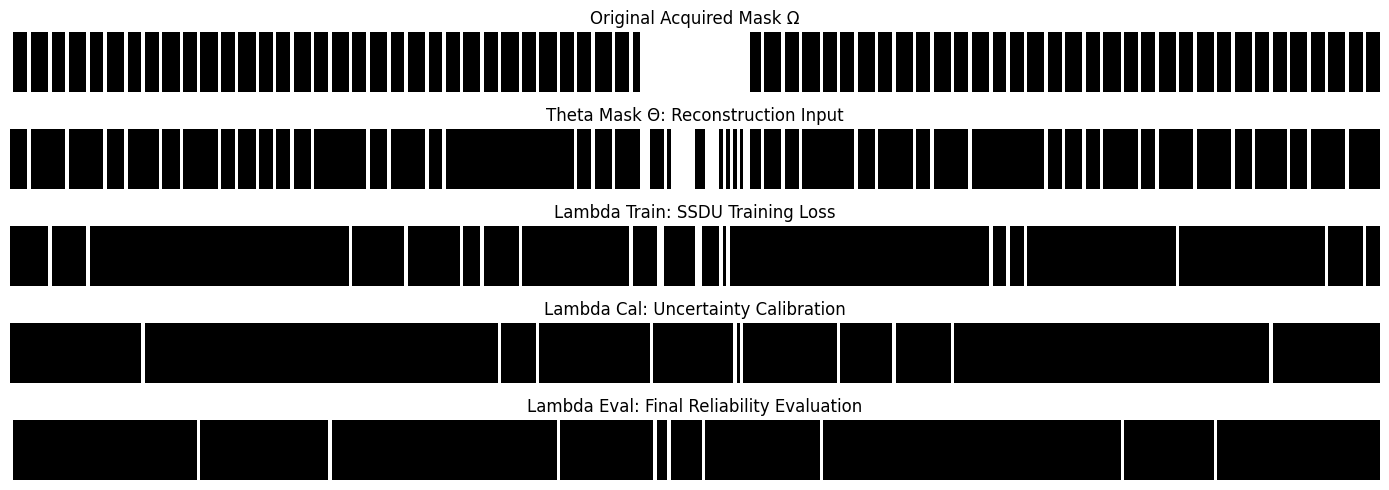

In [9]:
plt.figure(figsize=(14, 5))

plt.subplot(5, 1, 1)
plt.imshow(mask[None, :], cmap="gray", aspect="auto")
plt.title("Original Acquired Mask Ω")
plt.axis("off")

plt.subplot(5, 1, 2)
plt.imshow(theta_mask[None, :], cmap="gray", aspect="auto")
plt.title("Theta Mask Θ: Reconstruction Input")
plt.axis("off")

plt.subplot(5, 1, 3)
plt.imshow(lambda_train_mask[None, :], cmap="gray", aspect="auto")
plt.title("Lambda Train: SSDU Training Loss")
plt.axis("off")

plt.subplot(5, 1, 4)
plt.imshow(lambda_cal_mask[None, :], cmap="gray", aspect="auto")
plt.title("Lambda Cal: Uncertainty Calibration")
plt.axis("off")

plt.subplot(5, 1, 5)
plt.imshow(lambda_eval_mask[None, :], cmap="gray", aspect="auto")
plt.title("Lambda Eval: Final Reliability Evaluation")
plt.axis("off")

plt.tight_layout()
plt.show()

#**Train on Lambda_train, evaluate on Lambda_cal and Lambda_eval**

In [10]:
def run_four_way_reliability_experiment(
    kspace,
    mask,
    slice_index,
    coil_index=0,
    train_fraction=0.2,
    cal_fraction=0.1,
    eval_fraction=0.1,
    split_seed=42,
    model_seed=0,
    num_steps=50,
    num_samples=8,
    features=16,
    dropout_p=0.1,
    lr=1e-4,
    lambda_img=1e7,
):
    """
    Four-way SSDU reliability experiment.

    Train only on Lambda_train.
    Compute uncertainty-residual alignment separately on Lambda_cal and Lambda_eval.
    """

    np.random.seed(model_seed)
    torch.manual_seed(model_seed)

    # Select single-coil slice
    kspace_slice = kspace[slice_index]
    kspace_single = kspace_slice[coil_index]

    # Four-way SSDU split
    theta_mask, lambda_train_mask, lambda_cal_mask, lambda_eval_mask = split_acquired_mask_four_way(
        mask=mask,
        train_fraction=train_fraction,
        cal_fraction=cal_fraction,
        eval_fraction=eval_fraction,
        seed=split_seed,
    )

    # Prepare input from Theta only
    x_input, kspace_theta = prepare_single_coil_ssdu_input(
        kspace_single=kspace_single,
        theta_mask=theta_mask,
        normalize=True,
    )

    # Dropout model
    model = DropoutCNNReconstructor(
        in_channels=1,
        out_channels=1,
        features=features,
        dropout_p=dropout_p,
    )

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    loss_history = []
    ssdu_history = []
    img_history = []

    model.train()

    for step in range(num_steps):
        optimizer.zero_grad()

        x_pred = model(x_input)

        # Train ONLY on Lambda_train
        total_loss, ssdu_loss, img_loss = total_ssdu_training_loss(
            x_pred_tensor=x_pred,
            x_input_tensor=x_input,
            kspace_single=kspace_single,
            lambda_mask=lambda_train_mask,
            lambda_img=lambda_img,
        )

        total_loss.backward()
        optimizer.step()

        loss_history.append(total_loss.item())
        ssdu_history.append(ssdu_loss.item())
        img_history.append(img_loss.item())

    # Stochastic inference
    stochastic_outputs = stochastic_reconstructions(
        model=model,
        x_input_tensor=x_input,
        num_samples=num_samples,
    )

    mean_image, uncertainty_map = compute_mean_and_uncertainty(stochastic_outputs)

    # Calibration residual energy: Lambda_cal
    residual_energy_cal = backproject_lambda_residual(
        mean_image=mean_image,
        measured_kspace=kspace_single,
        lambda_mask=lambda_cal_mask,
    )

    # Evaluation residual energy: Lambda_eval
    residual_energy_eval = backproject_lambda_residual(
        mean_image=mean_image,
        measured_kspace=kspace_single,
        lambda_mask=lambda_eval_mask,
    )

    alignment_cal = map_alignment(
        uncertainty_map,
        residual_energy_cal,
    )

    alignment_eval = map_alignment(
        uncertainty_map,
        residual_energy_eval,
    )

    result = {
        "slice_index": slice_index,
        "coil_index": coil_index,
        "split_seed": split_seed,
        "model_seed": model_seed,
        "initial_train_ssdu_loss": ssdu_history[0],
        "final_train_ssdu_loss": ssdu_history[-1],
        "train_ssdu_reduction_percent": 100 * (ssdu_history[0] - ssdu_history[-1]) / ssdu_history[0],
        "initial_image_loss": img_history[0],
        "final_image_loss": img_history[-1],
        "alignment_cal": alignment_cal,
        "alignment_eval": alignment_eval,
        "loss_history": loss_history,
        "ssdu_history": ssdu_history,
        "img_history": img_history,
        "mean_image": mean_image,
        "uncertainty_map": uncertainty_map,
        "residual_energy_cal": residual_energy_cal,
        "residual_energy_eval": residual_energy_eval,
        "x_input": x_input.detach().cpu().numpy()[0, 0],
    }

    return result

**test it on slice 8 first:**

In [11]:
four_way_result_8 = run_four_way_reliability_experiment(
    kspace=kspace,
    mask=mask,
    slice_index=8,
    coil_index=0,
    split_seed=42,
    model_seed=0,
    num_steps=50,
    num_samples=8,
)

print("Slice:", four_way_result_8["slice_index"])
print("Initial train SSDU loss:", four_way_result_8["initial_train_ssdu_loss"])
print("Final train SSDU loss:", four_way_result_8["final_train_ssdu_loss"])
print("Training SSDU reduction %:", four_way_result_8["train_ssdu_reduction_percent"])
print("Calibration alignment:", four_way_result_8["alignment_cal"])
print("Evaluation alignment:", four_way_result_8["alignment_eval"])

Slice: 8
Initial train SSDU loss: 34236328.0
Final train SSDU loss: 20935760.0
Training SSDU reduction %: 38.849283135738155
Calibration alignment: 0.4237924124864184
Evaluation alignment: 0.5121614380155773


**Run four-way split across multiple slices**

In [12]:
four_way_multi_slice_results = []

for slice_index in [4, 8, 12]:
    print(f"\nRunning four-way experiment on slice {slice_index}...")

    result = run_four_way_reliability_experiment(
        kspace=kspace,
        mask=mask,
        slice_index=slice_index,
        coil_index=0,
        train_fraction=0.2,
        cal_fraction=0.1,
        eval_fraction=0.1,
        split_seed=42,
        model_seed=0,
        num_steps=50,
        num_samples=8,
        features=16,
        dropout_p=0.1,
        lr=1e-4,
        lambda_img=1e7,
    )

    four_way_multi_slice_results.append({
        "slice_index": slice_index,
        "initial_train_ssdu_loss": result["initial_train_ssdu_loss"],
        "final_train_ssdu_loss": result["final_train_ssdu_loss"],
        "train_ssdu_reduction_percent": result["train_ssdu_reduction_percent"],
        "alignment_cal": result["alignment_cal"],
        "alignment_eval": result["alignment_eval"],
    })

four_way_multi_slice_df = pd.DataFrame(four_way_multi_slice_results)
four_way_multi_slice_df


Running four-way experiment on slice 4...

Running four-way experiment on slice 8...

Running four-way experiment on slice 12...


,slice_index,initial_train_ssdu_loss,final_train_ssdu_loss,train_ssdu_reduction_percent,alignment_cal,alignment_eval
0,4,77422928.0,40357816.0,47.873560,0.392745,0.404839
1,8,34236328.0,20935760.0,38.849283,0.423792,0.512161
2,12,55932464.0,35439100.0,36.639480,0.432562,0.518162


In [13]:
print(four_way_multi_slice_df)

print("\nMean training SSDU reduction %:", four_way_multi_slice_df["train_ssdu_reduction_percent"].mean())
print("Std training SSDU reduction %:", four_way_multi_slice_df["train_ssdu_reduction_percent"].std())

print("\nMean calibration alignment:", four_way_multi_slice_df["alignment_cal"].mean())
print("Std calibration alignment:", four_way_multi_slice_df["alignment_cal"].std())

print("\nMean evaluation alignment:", four_way_multi_slice_df["alignment_eval"].mean())
print("Std evaluation alignment:", four_way_multi_slice_df["alignment_eval"].std())
print("Min evaluation alignment:", four_way_multi_slice_df["alignment_eval"].min())
print("Max evaluation alignment:", four_way_multi_slice_df["alignment_eval"].max())

   slice_index  initial_train_ssdu_loss  final_train_ssdu_loss  \
0            4               77422928.0             40357816.0   
1            8               34236328.0             20935760.0   
2           12               55932464.0             35439100.0   

   train_ssdu_reduction_percent  alignment_cal  alignment_eval  
0                     47.873560       0.392745        0.404839  
1                     38.849283       0.423792        0.512161  
2                     36.639480       0.432562        0.518162  

Mean training SSDU reduction %: 41.120774449377706
Std training SSDU reduction %: 5.951545459625913

Mean calibration alignment: 0.4163666003789969
Std calibration alignment: 0.020921128027440235

Mean evaluation alignment: 0.47838748294110234
Std evaluation alignment: 0.0637655234827069
Min evaluation alignment: 0.40483894917749425
Max evaluation alignment: 0.5181620616302354


#**Test src/four_way_reliability.py**

In [6]:
%cd /content/reliability-aware-ssdu-mri
!git pull

/content/reliability-aware-ssdu-mri
Already up to date.


In [7]:
import sys
import importlib

sys.path.insert(0, "/content/reliability-aware-ssdu-mri/src")

import four_way_reliability
importlib.reload(four_way_reliability)

from four_way_reliability import run_four_way_reliability_experiment

print("four_way_reliability.py imported successfully.")

four_way_reliability.py imported successfully.


**test it on slice 8:**

In [8]:
test_four_way_result = run_four_way_reliability_experiment(
    kspace=kspace,
    mask=mask,
    slice_index=8,
    coil_index=0,
    train_fraction=0.2,
    cal_fraction=0.1,
    eval_fraction=0.1,
    split_seed=42,
    model_seed=0,
    num_steps=50,
    num_samples=8,
    features=16,
    dropout_p=0.1,
    lr=1e-4,
    lambda_img=1e7,
)

print("Slice:", test_four_way_result["slice_index"])
print("Initial train SSDU loss:", test_four_way_result["initial_train_ssdu_loss"])
print("Final train SSDU loss:", test_four_way_result["final_train_ssdu_loss"])
print("Training SSDU reduction %:", test_four_way_result["train_ssdu_reduction_percent"])
print("Calibration alignment:", test_four_way_result["alignment_cal"])
print("Evaluation alignment:", test_four_way_result["alignment_eval"])

Slice: 8
Initial train SSDU loss: 34236328.0
Final train SSDU loss: 20935760.0
Training SSDU reduction %: 38.849283135738155
Calibration alignment: 0.4237925426958646
Evaluation alignment: 0.5121615600507005


#**Run four-way reliability test on all 16 slices**

In [9]:
all_slice_results = []

for slice_index in range(kspace.shape[0]):
    print(f"\nRunning four-way experiment on slice {slice_index}...")

    result = run_four_way_reliability_experiment(
        kspace=kspace,
        mask=mask,
        slice_index=slice_index,
        coil_index=0,
        train_fraction=0.2,
        cal_fraction=0.1,
        eval_fraction=0.1,
        split_seed=42,
        model_seed=0,
        num_steps=50,
        num_samples=8,
        features=16,
        dropout_p=0.1,
        lr=1e-4,
        lambda_img=1e7,
    )

    all_slice_results.append({
        "slice_index": slice_index,
        "initial_train_ssdu_loss": result["initial_train_ssdu_loss"],
        "final_train_ssdu_loss": result["final_train_ssdu_loss"],
        "train_ssdu_reduction_percent": result["train_ssdu_reduction_percent"],
        "alignment_cal": result["alignment_cal"],
        "alignment_eval": result["alignment_eval"],
    })

all_slice_df = pd.DataFrame(all_slice_results)
all_slice_df


Running four-way experiment on slice 0...

Running four-way experiment on slice 1...

Running four-way experiment on slice 2...

Running four-way experiment on slice 3...

Running four-way experiment on slice 4...

Running four-way experiment on slice 5...

Running four-way experiment on slice 6...

Running four-way experiment on slice 7...

Running four-way experiment on slice 8...

Running four-way experiment on slice 9...

Running four-way experiment on slice 10...

Running four-way experiment on slice 11...

Running four-way experiment on slice 12...

Running four-way experiment on slice 13...

Running four-way experiment on slice 14...

Running four-way experiment on slice 15...


,slice_index,initial_train_ssdu_loss,final_train_ssdu_loss,train_ssdu_reduction_percent,alignment_cal,alignment_eval
0,0,195396224.0,88244464.0,54.838194,0.334921,0.381174
1,1,252891232.0,124315192.0,50.842427,0.355052,0.413082
2,2,134028280.0,67938600.0,49.310250,0.375022,0.438849
3,3,86146960.0,44620792.0,48.203869,0.343066,0.453341
4,4,77422920.0,40357816.0,47.873555,0.392746,0.404839
5,5,70205912.0,37586504.0,46.462480,0.347724,0.458414
6,6,36439496.0,21719716.0,40.395125,0.391535,0.446922
7,7,41045204.0,24071168.0,41.354493,0.371006,0.466606
8,8,34236328.0,20935760.0,38.849283,0.423793,0.512162
9,9,39558752.0,24140456.0,38.975689,0.428911,0.502314


In [10]:
print(all_slice_df)

print("\nMean training SSDU reduction %:", all_slice_df["train_ssdu_reduction_percent"].mean())
print("Std training SSDU reduction %:", all_slice_df["train_ssdu_reduction_percent"].std())

print("\nMean calibration alignment:", all_slice_df["alignment_cal"].mean())
print("Std calibration alignment:", all_slice_df["alignment_cal"].std())
print("Min calibration alignment:", all_slice_df["alignment_cal"].min())
print("Max calibration alignment:", all_slice_df["alignment_cal"].max())

print("\nMean evaluation alignment:", all_slice_df["alignment_eval"].mean())
print("Std evaluation alignment:", all_slice_df["alignment_eval"].std())
print("Min evaluation alignment:", all_slice_df["alignment_eval"].min())
print("Max evaluation alignment:", all_slice_df["alignment_eval"].max())

    slice_index  initial_train_ssdu_loss  final_train_ssdu_loss  \
0             0              195396224.0             88244464.0   
1             1              252891232.0            124315192.0   
2             2              134028280.0             67938600.0   
3             3               86146960.0             44620792.0   
4             4               77422920.0             40357816.0   
5             5               70205912.0             37586504.0   
6             6               36439496.0             21719716.0   
7             7               41045204.0             24071168.0   
8             8               34236328.0             20935760.0   
9             9               39558752.0             24140456.0   
10           10               38363132.0             23740318.0   
11           11               50481560.0             31555356.0   
12           12               55932456.0             35439108.0   
13           13               73542904.0             48026880.